In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_poisson_deviance

test_predictions = pd.read_parquet(Path("data") / "test_predictions.parquet")
glm_pipeline = joblib.load(Path("data") / "glm_pipeline.joblib")
lgbm_pipeline = joblib.load(Path("data") / "lgbm_pipeline.joblib")
baseline_rate = test_predictions["baseline_rate"].iloc[0]
feature_columns = ["Area", "VehPower", "VehAge", "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
print(test_predictions.shape, baseline_rate)

(135603, 15) 0.10061790715750009


count    135603.000000
mean         -0.172420
std           0.520967
min          -2.136192
25%          -0.369023
50%          -0.271808
75%          -0.153588
max           5.771937
dtype: float64
share positive 0.050153757660228754 share negative 0.9498462423397712


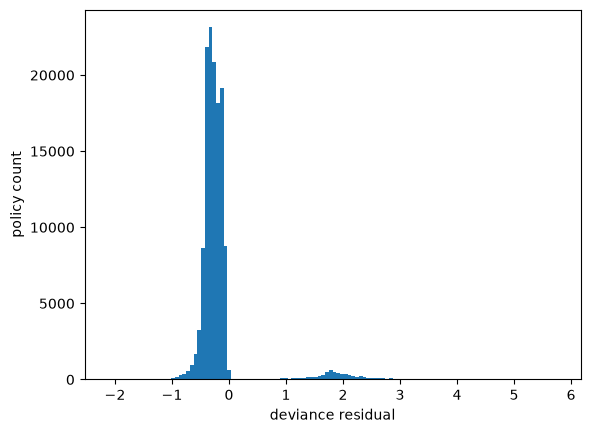

In [2]:
actual_claims = test_predictions["ClaimNb"].to_numpy(dtype=float)
expected_claims = (test_predictions["Exposure"] * test_predictions["lgbm_predicted_rate"]).to_numpy()
log_term = np.where(actual_claims > 0, actual_claims * np.log(np.where(actual_claims > 0, actual_claims, 1.0) / expected_claims), 0.0)
unit_deviance = 2.0 * (log_term - (actual_claims - expected_claims))
deviance_residual = np.sign(actual_claims - expected_claims) * np.sqrt(np.clip(unit_deviance, 0.0, None))
test_predictions["expected_claims"] = expected_claims
test_predictions["deviance_residual"] = deviance_residual

print(pd.Series(deviance_residual).describe())
print("share positive", float((deviance_residual > 0).mean()), "share negative", float((deviance_residual < 0).mean()))
plt.figure()
plt.hist(deviance_residual, bins=120)
plt.xlabel("deviance residual")
plt.ylabel("policy count")
plt.show()

I rank policies by absolute deviance residual because raw residuals mostly repeat the claim-count ranking. The mean is −0.17 because 95.0% of policies have no claim and sit below their positive expected count. Deviance residuals need not average to zero; total calibration is separate.

In [3]:
largest_residuals = test_predictions.loc[
    test_predictions["deviance_residual"].abs().sort_values(ascending=False).index[:10]
]
print(largest_residuals)

          IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus VehBrand   VehGas  Density Region  glm_predicted_rate  lgbm_predicted_rate  baseline_rate  expected_claims  deviance_residual
321512  2248174        9  0.080000    D         4      12       52          50       B1  Regular      824    R91            0.065936             6.914113       0.100618         0.553129           5.771937
644989  6017766        2  0.010000    B         5       5       36          50      B12  Regular       66    R93            0.062725             0.039320       0.100618         0.000393           5.489823
25347     54009        4  0.560000    A         4       4       46          50       B4   Diesel       29    R24            0.066653             0.075360       0.100618         0.042202           5.338267
2838       5896        2  0.002732    A        11       0       36          50      B12   Diesel       35    R54            0.166424             0.225138       0.100618         0.0

All ten largest residuals are positive; seven combine at least two claims with `Exposure ≤ 0.09`. This fits the early-termination hypothesis, but dates and termination reasons are unavailable. The largest case is already flagged: its matching train profile has 25 claims in 1.94 exposure-years, and LightGBM predicts 6.91 claims/year, or 0.55 expected claims for this policy.

In [4]:
def weighted_gini(claim_count, exposure, score):
    ranked = (
        pd.DataFrame({"claim_count": claim_count, "exposure": exposure, "score": score})
        .groupby("score", as_index=False)
        .agg(claim_count=("claim_count", "sum"), exposure=("exposure", "sum"))
        .sort_values("score", ascending=False)
    )
    exposure_share = np.r_[0.0, ranked["exposure"].cumsum() / ranked["exposure"].sum()]
    claims_share = np.r_[0.0, ranked["claim_count"].cumsum() / ranked["claim_count"].sum()]
    return 2.0 * np.trapezoid(claims_share, exposure_share) - 1.0


def evaluate_subset(frame):
    target_rate = frame["ClaimNb"] / frame["Exposure"]
    rows = []
    for model_name, predicted_rate in [
        ("Baseline", pd.Series(baseline_rate, index=frame.index)),
        ("GLM", frame["glm_predicted_rate"]),
        ("LightGBM", frame["lgbm_predicted_rate"]),
    ]:
        predicted_claims = float((frame["Exposure"] * predicted_rate).sum())
        rows.append(
            {
                "model": model_name,
                "mean_poisson_deviance": mean_poisson_deviance(target_rate, predicted_rate, sample_weight=frame["Exposure"]),
                "actual_claims": int(frame["ClaimNb"].sum()),
                "predicted_claims": predicted_claims,
                "predicted_to_actual": predicted_claims / float(frame["ClaimNb"].sum()),
                "gini": weighted_gini(frame["ClaimNb"], frame["Exposure"], predicted_rate),
            }
        )
    return pd.DataFrame(rows)


full_test = evaluate_subset(test_predictions)
restricted_test = evaluate_subset(test_predictions[test_predictions["Exposure"] >= 0.02])
print("full test rows", len(test_predictions), "restricted rows", int((test_predictions["Exposure"] >= 0.02).sum()))
print(full_test)
print(restricted_test)

full test rows 135603 restricted rows 132886
      model  mean_poisson_deviance  actual_claims  predicted_claims  predicted_to_actual      gini
0  Baseline               0.625530           7236       7205.463920             0.995780  0.000000
1       GLM               0.592996           7236       7221.220552             0.997958  0.289518
2  LightGBM               0.570219           7236       7230.773845             0.999278  0.339571
      model  mean_poisson_deviance  actual_claims  predicted_claims  predicted_to_actual      gini
0  Baseline               0.615307           7176       7203.414067             1.003820  0.000000
1       GLM               0.583618           7176       7218.306091             1.005895  0.287806
2  LightGBM               0.561382           7176       7227.674575             1.007201  0.337809


Restricting evaluation to `Exposure ≥ 0.02` excludes 2,717 rows and lowers deviance for every model, but barely changes relative gains or Gini. LightGBM remains best. Its calibration moves from 0.07% low to 0.72% high, so the restriction affects totals but not the model choice.

In [5]:
X_test = test_predictions[feature_columns]
target_rate = test_predictions["ClaimNb"] / test_predictions["Exposure"]
exposure_weight = test_predictions["Exposure"]

permutation_result = permutation_importance(
    lgbm_pipeline,
    X_test,
    target_rate,
    scoring=make_scorer(mean_poisson_deviance, greater_is_better=False),
    n_repeats=10,
    random_state=42,
    sample_weight=exposure_weight,
)
permutation_ranking = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance_mean": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(permutation_ranking)

      feature  importance_mean  importance_std
0      VehAge         0.043723        0.000976
1  BonusMalus         0.040743        0.000826
2    VehBrand         0.020755        0.000911
3     DrivAge         0.011818        0.000799
4    VehPower         0.009690        0.000689
5      VehGas         0.007505        0.000429
6      Region         0.006207        0.000304
7     Density         0.005196        0.000441
8        Area         0.000506        0.000095


`VehAge` and `BonusMalus` cause the largest deviance increases when shuffled: 0.0437 and 0.0407. `Area` adds almost nothing once the other features are present (0.0005), consistent with its overlap with `Density`. These are predictive, not causal, importances.

In [6]:
def decile_frequencies(frame, rate_column):
    ordered = frame.sort_values(rate_column, kind="mergesort").copy()
    exposure_position = (ordered["Exposure"].cumsum() - 0.5 * ordered["Exposure"]) / ordered["Exposure"].sum()
    ordered["risk_decile"] = np.clip(np.floor(10 * exposure_position).astype(int) + 1, 1, 10)
    ordered["predicted_claims"] = ordered["Exposure"] * ordered[rate_column]
    grouped = ordered.groupby("risk_decile").agg(
        exposure=("Exposure", "sum"),
        actual_claims=("ClaimNb", "sum"),
        predicted_claims=("predicted_claims", "sum"),
    )
    grouped["observed_frequency"] = grouped["actual_claims"] / grouped["exposure"]
    grouped["predicted_frequency"] = grouped["predicted_claims"] / grouped["exposure"]
    return grouped.reset_index()


lgbm_decile_table = decile_frequencies(test_predictions, "lgbm_predicted_rate")
print(lgbm_decile_table)
print("observed top/bottom decile ratio", lgbm_decile_table.loc[9, "observed_frequency"] / lgbm_decile_table.loc[0, "observed_frequency"])
print("predicted top/bottom decile ratio", lgbm_decile_table.loc[9, "predicted_frequency"] / lgbm_decile_table.loc[0, "predicted_frequency"])

   risk_decile     exposure  actual_claims  predicted_claims  observed_frequency  predicted_frequency
0            1  7160.984522            269        277.666527            0.037565             0.038775
1            2  7160.975747            376        374.030673            0.052507             0.052232
2            3  7161.855432            436        437.157615            0.060878             0.061040
3            4  7160.783090            436        490.537798            0.060887             0.068503
4            5  7161.908843            563        540.375831            0.078610             0.075451
5            6  7161.087372            627        587.283895            0.087557             0.082010
6            7  7160.536562            633        640.744226            0.088401             0.089483
7            8  7161.419508            731        728.849659            0.102075             0.101774
8            9  7161.622658            903        942.144488            0.126089  

Observed frequency rises from 0.0376 in decile 1 to 0.3159 in decile 10, an 8.4× spread; the model predicts 8.0×. The top decile is the first place to review rating and underwriting. This is claim frequency, not pure premium: pricing also needs severity, costs and margin.

In [7]:
from sklearn.model_selection import train_test_split

claims_prepared = pd.read_parquet(Path("data") / "claims_prepared.parquet")
train_index, test_index = train_test_split(
    claims_prepared.index,
    test_size=0.20,
    stratify=claims_prepared["ClaimNb"].gt(0),
    random_state=42,
)
train_rows = claims_prepared.loc[train_index]

profile = claims_prepared.loc[claims_prepared["IDpol"] == 2248174, feature_columns].iloc[0]
profile_group = train_rows[(train_rows[feature_columns] == profile).all(axis=1)]
print(profile.to_dict())
print(
    "profile group",
    len(profile_group),
    float(profile_group["Exposure"].sum()),
    int(profile_group["ClaimNb"].sum()),
    profile_group["ClaimNb"].sum() / profile_group["Exposure"].sum(),
)

low_exposure_train = train_rows[train_rows["Exposure"] < 0.02]
print(
    "train Exposure < 0.02",
    len(low_exposure_train),
    float(low_exposure_train["Exposure"].sum()),
    int(low_exposure_train["ClaimNb"].sum()),
    low_exposure_train["ClaimNb"].sum() / low_exposure_train["Exposure"].sum(),
)

{'Area': 'D', 'VehPower': 4, 'VehAge': 12, 'DrivAge': 52, 'BonusMalus': 50, 'VehBrand': 'B1', 'VehGas': 'Regular', 'Density': 824, 'Region': 'R91'}
profile group 10 1.9400000000000002 25 12.886597938144329
train Exposure < 0.02 10886 80.87282190449278 302 3.734258220353045
